# Short Burst Implementation

@author: taiyyoson

Implementing Short Bursts Analysis on SC shapefile data constructed from MAUP.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.tree import bipartition_tree
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial
from gerrychain.metrics import efficiency_gap
from gerrychain.optimization import SingleMetricOptimizer, Gingleator
import numpy as np
import time
import os

In [4]:
sc_gdf = gpd.read_file("./SC/SC.shp")
sc_from_gpd_graph = Graph.from_geodataframe(sc_gdf, adjacency="rook") ## creating graph from geodataframe

## setting up initial markov chain model

my_updaters = {
        "cut_edges": cut_edges,
        "population": Tally("TOTPOP", alias="population"),
    }

## creating initial partition
initial_partition = Partition(
    sc_from_gpd_graph, 
    assignment="SEND",
    
    updaters=my_updaters
)

## using RECOM on the random walk, need ideal population
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)
proposal = partial(recom,
                   pop_col="TOTPOP",
                   pop_target=ideal_population,
                   epsilon=0.1,
                   node_repeats=2,
                   method = partial(
                        bipartition_tree,
                        max_attempts=100,
                        allow_pair_reselection=True  # <-- This is the only change
                    )
)


## all used for building markov chain
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"])
)
pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.1)





In [6]:
def num_cut_edges(partition):
    return len(partition["cut_edges"])

optimizer = SingleMetricOptimizer(
    proposal=proposal,
    constraints=pop_constraint,
    initial_state=initial_partition,
    optimization_metric=num_cut_edges,
    maximize=False
)


total_steps = 10000

# Short Bursts
min_scores_sb = np.zeros(total_steps)
scores_sb = np.zeros(total_steps)
for i, part in enumerate(optimizer.short_bursts(5, 2000, with_progress_bar=True)):
    min_scores_sb[i] = optimizer.best_score
    scores_sb[i] = optimizer.score(part)

# Simulated Annealing
min_scores_anneal = np.zeros(total_steps)
scores_anneal = np.zeros(total_steps)
for i, part in enumerate(
    optimizer.simulated_annealing(
        total_steps,
        optimizer.jumpcycle_beta_function(200, 800),
        beta_magnitude=1,
        with_progress_bar=True
    )
):
    min_scores_anneal[i] = optimizer.best_score
    scores_anneal[i] = optimizer.score(part)

# Tilted Runs
min_scores_tilt = np.zeros(total_steps)
scores_tilt = np.zeros(total_steps)
for i, part in enumerate(optimizer.tilted_run(total_steps, p=0.125, with_progress_bar=True)):
    min_scores_tilt[i] = optimizer.best_score
    scores_tilt[i] = optimizer.score(part)

100%|██████████| 10000/10000 [01:10<00:00, 141.15it/s]


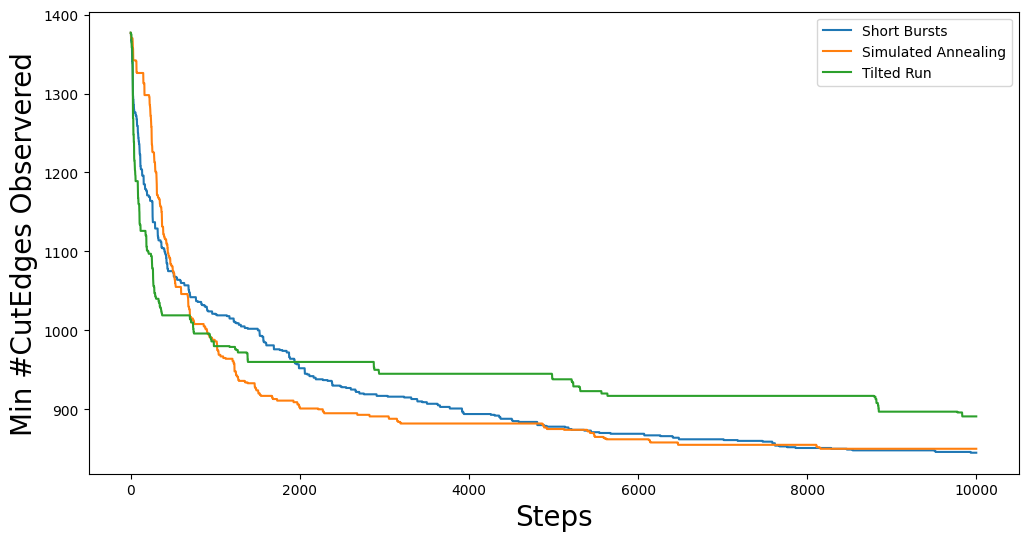

In [7]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(min_scores_sb, label="Short Bursts")
plt.plot(min_scores_anneal, label="Simulated Annealing")
plt.plot(min_scores_tilt, label="Tilted Run")
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Min #CutEdges Observered", fontsize=20)
plt.legend()
plt.show()